<a href="https://colab.research.google.com/github/MaryamAmjad2/PyTorch/blob/main/02_Neural_Networks_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification

## Making a Toy  Dataset to Classifiy if the point belongs to circle 1 or circle 2

In [ ]:
import sklearn
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
n_samples=1000

#Create circles
X,y= make_circles(n_samples,
                  noise=0.03,
                  random_state=42)

In [ ]:
len(X),len(y)

(1000, 1000)

In [ ]:
print(f' First 5 Samples of X : {X[:5]}')
print(f' First 5 Samples of y : {y[:5]}')

 First 5 Samples of X : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
 First 5 Samples of y : [1 1 1 1 0]


### Make DataFrame of Circle Data

In [ ]:
circles=pd.DataFrame(
    {
      "X1":X[:,0],
      "X2": X[:,1],
      "y":y
    }

)

circles.head(10)

,X1,X2,y
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [ ]:
# Check data

print(circles.columns)
circles['y'].value_counts()

Index(['X1', 'X2', 'y'], dtype='object')


,count
y,
1,500
0,500


# visulaize

<function matplotlib.pyplot.show(close=None, block=None)>

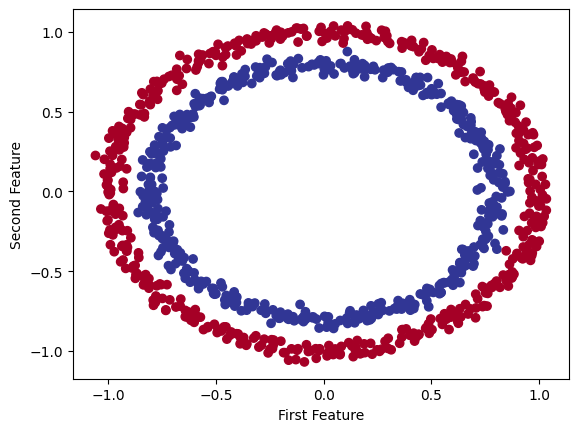

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)
plt.xlabel('First Feature')
plt.ylabel('Second Feature')
plt.show

# Check Input and Output Shape

In [ ]:
X.shape,y.shape

((1000, 2), (1000,))

## Turn Data into  Tensor

In [ ]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [ ]:
X[:2,],y[:4]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533]]),
 tensor([1., 1., 1., 1.]))

# Train And Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=42)

# Steps for Modeling

## Device Agnostics

In [ ]:
# device='cuda' if torch.cuda.is_available() else 'cpu'

##1. Buildiing a Model

In [ ]:
X_train.shape

torch.Size([800, 2])

In [ ]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()



    # Create 2 nn.Linear Layers
    self.layer_1=nn.Linear(in_features=2,out_features=4)
    self.layer_2=nn.Linear(in_features=4,out_features=1)


  def forward(self,x:torch):
    return self.layer_2(self.layer_1(x))  #x goes in L1 and that Goes in L2






In [ ]:
model_0=CircleModelV0().to(device)

In [ ]:
next(model_0.parameters()).device

device(type='cuda', index=0)

#Using nn.Sequential

In [ ]:
## Replicating Above Model with nn.Sequential
# It saves you from writing a full class with __init__ and forward().



In [ ]:
model_0=nn.Sequential(
    nn.Linear(in_features=2,out_features=16),
    # nn.ReLU(),
    nn.Linear(in_features=16,out_features=4),
    # nn.ReLU(),
    nn.Linear(in_features=4,out_features=1),
).to(device)

# Make Predictions

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1045, -0.3301],
                      [ 0.1802, -0.3258],
                      [-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386],
                      [-0.6007,  0.5459],
                      [ 0.1177, -0.2296],
                      [ 0.4370,  0.1102],
                      [ 0.5713,  0.0773],
                      [-0.2230,  0.1900],
                      [-0.1918,  0.2976],
                      [ 0.6313,  0.4087],
                      [-0.3091,  0.4082],
                      [ 0.1265,  0.3591]], device='cuda:0')),
             ('0.bias',
              tensor([-0.4310, -0.7000, -0.2732, -0.5424,  0.5802,  0.2037,  0.2929,  0.2236,
                      -0.0123,  0.5534, -0.5024,  0.0445, -0.4826,  0.2180, -0.2435,  0.2167],
                     device='cuda:0')),
             ('1.weight',
   

In [ ]:
with torch.inference_mode():
  un_trained_preds=model_0(X_test.to(device))
print(f"length of predictions is {len(un_trained_preds)} ")
print(f"Shape of predictions is {un_trained_preds.shape} ")
print(y_test.shape)

print(f'\n First 10 Prediction :\n {un_trained_preds[:10]}')
print(f'\n First 10 Labels :\n{y_test[:10]}')

length of predictions is 200 
Shape of predictions is torch.Size([200, 1]) 
torch.Size([200])

 First 10 Prediction :
 tensor([[-0.4388],
        [-0.5118],
        [-0.4899],
        [-0.4233],
        [-0.8750],
        [-0.9166],
        [-0.8170],
        [-0.9128],
        [-0.4736],
        [-0.5209]], device='cuda:0')

 First 10 Labels :
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


# Setting Up Loss Fun

For Binary Classification we use BCE Loss function.

For Regression we use MSE,MAE

In [ ]:
loss_fn=nn.BCEWithLogitsLoss() ## Automatically applies sigmoid

So instead of doing this manually:

probs = torch.sigmoid(logits)
loss = nn.BCELoss()(probs, targets)

You do this in one step:


loss = nn.BCEWithLogitsLoss()(logits, targets)

# Optimizer

Two Most common are


*   SGD
*   Adam



In [ ]:
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.1
                          )

# Evaluation Function

In [ ]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct)/len(y_pred)*100
  return acc

# Train Model

In [ ]:
device

'cuda'

In [ ]:
epochs=1000
torch.cuda.manual_seed(42)  # For GPU
torch.manual_seed(42)


# Putting data on device to avoid error
X_train,y_train= X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)


for epoch in range(epochs):

  model_0.train()
  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))  # Turn logits  into prob -> labels

  #  Cal Loss and Accuracy
  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  #Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    # Cal Test Loss and Accuracy
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_test,test_pred)

  if epoch%100==0:
    print(f'Train loss {loss.item():.5f} | Train Accuracy {acc}')
    print(f'Test loss {test_loss.item():.5f} | Test Accuracy {test_acc}')

Train loss 0.75000 | Train Accuracy 50.0
Test loss 0.74236 | Test Accuracy 50.0
Train loss 0.69377 | Train Accuracy 48.875
Test loss 0.69453 | Test Accuracy 52.0
Train loss 0.69310 | Train Accuracy 50.125
Test loss 0.69401 | Test Accuracy 49.0
Train loss 0.69301 | Train Accuracy 50.875
Test loss 0.69414 | Test Accuracy 46.0
Train loss 0.69299 | Train Accuracy 51.5
Test loss 0.69431 | Test Accuracy 47.0
Train loss 0.69298 | Train Accuracy 51.0
Test loss 0.69444 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.37500000000001
Test loss 0.69453 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.37500000000001
Test loss 0.69458 | Test Accuracy 44.5
Train loss 0.69298 | Train Accuracy 51.5
Test loss 0.69462 | Test Accuracy 45.0
Train loss 0.69298 | Train Accuracy 51.24999999999999
Test loss 0.69464 | Test Accuracy 45.0


In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1398, -0.3346],
                      [ 0.2095, -0.3307],
                      [-0.0761, -0.2882],
                      [ 0.4465, -0.5534],
                      [-0.2921, -0.2033],
                      [-0.3946,  0.0606],
                      [-0.6604,  0.6306],
                      [-0.5832,  0.5403],
                      [ 0.1219, -0.2287],
                      [ 0.4470,  0.1119],
                      [ 0.5858,  0.0775],
                      [-0.2105,  0.1886],
                      [-0.1777,  0.2940],
                      [ 0.6648,  0.4061],
                      [-0.2704,  0.4006],
                      [ 0.0755,  0.3673]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3984, -0.6673, -0.2651, -0.5659,  0.6033,  0.2368,  0.3364,  0.2501,
                      -0.0135,  0.5504, -0.4936,  0.0550, -0.4614,  0.2406, -0.1996,  0.1658],
                     device='cuda:0')),
             ('1.weight',
   

In [ ]:
# View the first 5 output of sample y and compare it to the y_test

model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test.to(device))[:5]
print(y_logits)


# print(y_test[:5])


tensor([[ 0.0278],
        [ 0.0512],
        [-0.0315],
        [ 0.0446],
        [-0.0285]], device='cuda:0')


## Using sigmoid on Our Model Logits

In [ ]:
y_preds_prob=torch.sigmoid(y_logits)

print(y_preds_prob)
torch.round(y_preds_prob)


tensor([[0.5069],
        [0.5128],
        [0.4921],
        [0.5111],
        [0.4929]], device='cuda:0')


tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.]], device='cuda:0')


*   y_perd_prob>=0.5 y=1
*   y_pred_prob>0.5  y=0




In [ ]:
# Find the predicted labels

y_preds=torch.round(y_preds_prob)
print(y_preds)

# IN FULL(logits -> pred probs -> pred labels)

y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check Equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))




tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.]], device='cuda:0')
tensor([True, True, True, True, True], device='cuda:0')


#  Visualize

Model  is not learning anything so we are going to visualize some predictions

## Import Helper Function


In [ ]:
import requests
from pathlib import Path

# Download Helper Function
if Path('helper_function.py').is_file():
  print("Yes")
else:
  print("Downloading ")
  request=requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_function.py','wb') as f:
    f.write(request.content)

from helper_function import plot_predictions, plot_decision_boundary

Yes


(None,)

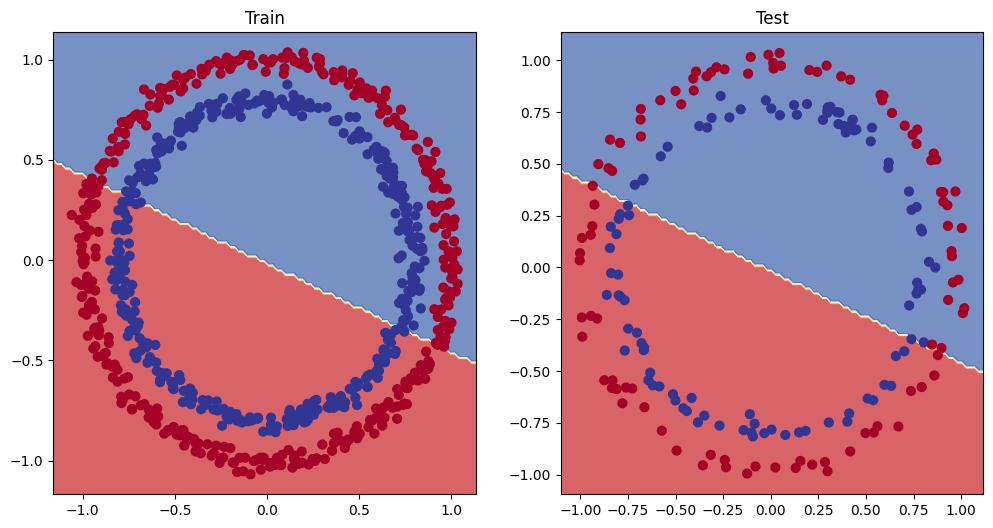

In [ ]:
# Plot Decision Boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train),
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test),

#5. Improve Model



1.   Add more layers.
2.   Add more hidden units.


1.   Fit for Longer (more epochs)
2.   Change Activation function.


1.   Change Learning Rate
2.   Change Loss Function







## Model

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    # nn.ReLU(),
    self.layer_2=nn.Linear(in_features=10,out_features=10)

    self.layer_3=nn.Linear(in_features=10,out_features=1)



  def forward(self,x:torch):
    return self.layer_3(self.layer_2(self.layer_1(x)))


model_1=CircleModelV1()
# next(model_1.parameters()).device ## model is on CPU
# model_1.to(device)
# next(model_1.parameters())
model_1 = model_1.to(device)






## Loss


In [ ]:
loss_fn=torch.nn.BCEWithLogitsLoss()

## Optimizer

In [ ]:
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

## Training and Eval Loop

In [ ]:
# Putting on same device

X_train, y_train,X_test,y_test= X_train.to(device),y_train.to(device),X_test.to(device),y_test.to(device)

In [ ]:
epochs=1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)


# Putting on same device

X_train, y_train= X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):

  model_1.train()

  # Forward Pass
  y_logits=model_1(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))


  # Calculate Loss and Accuracy
  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


  # Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits=model_1(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_test,test_pred)

  if epoch%100 == 0:
    print(f'Train loss {loss.item():.5f} | Train Accuracy {acc}')
    print(f'Test loss {test_loss.item():.5f} | Test Accuracy {test_acc}')


Train loss 0.69396 | Train Accuracy 50.875
Test loss 0.69261 | Test Accuracy 51.0
Train loss 0.69305 | Train Accuracy 50.375
Test loss 0.69379 | Test Accuracy 48.0
Train loss 0.69299 | Train Accuracy 51.125
Test loss 0.69437 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.625
Test loss 0.69458 | Test Accuracy 45.0
Train loss 0.69298 | Train Accuracy 51.125
Test loss 0.69465 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.0
Test loss 0.69467 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.0
Test loss 0.69468 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.0
Test loss 0.69468 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.0
Test loss 0.69468 | Test Accuracy 46.0
Train loss 0.69298 | Train Accuracy 51.0
Test loss 0.69468 | Test Accuracy 46.0


(None,)

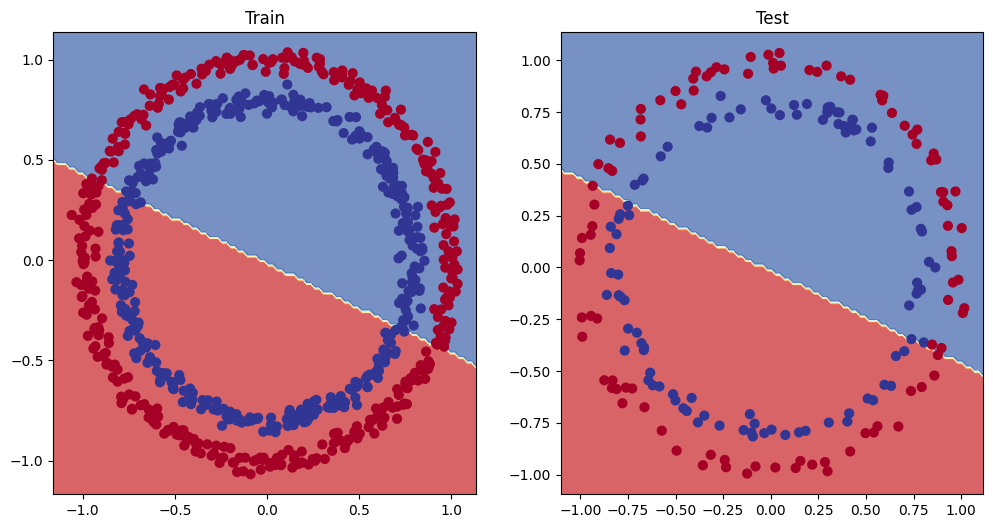

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train),
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test),

## Checking if our Model will fit on a straight line.

In [ ]:
w=0.7
b=0.3
start =0
end=1

step=0.01

# Create Data
X_regression=torch.arange(start,end,step).unsqueeze(dim=1)
y_regression=w*X_regression + b

# Check Data
print(len(X_regression))
print(X_regression[:3],y_regression[:3])




100
tensor([[0.0000],
        [0.0100],
        [0.0200]]) tensor([[0.3000],
        [0.3070],
        [0.3140]])


In [ ]:
# Create Train and test split

train_split= int(0.8 * len(X_regression))
X_train_reg=X_regression[:train_split]
y_train_reg=y_regression[:train_split]

X_test_reg=X_regression[train_split:]
y_test_reg=y_regression[train_split:]

print(len(X_train_reg), len(y_train_reg),len(X_test_reg),len(y_test_reg))

80 80 20 20


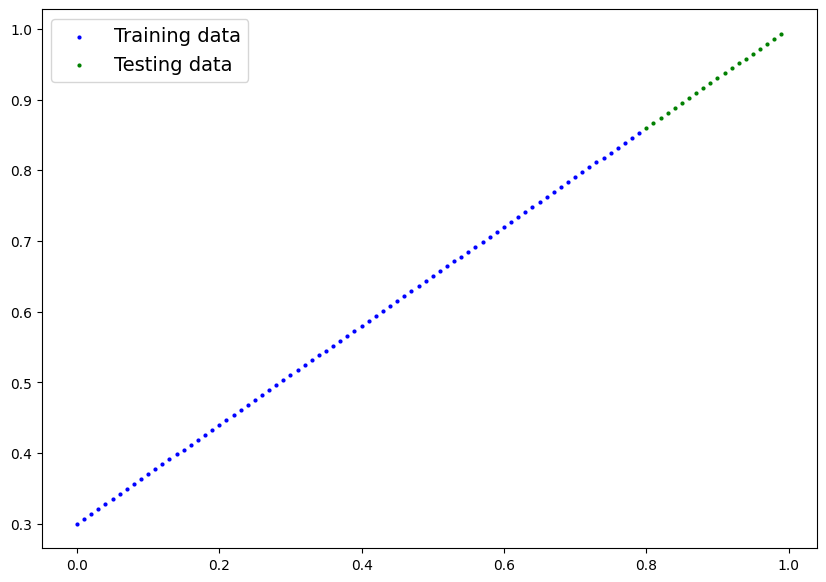

In [ ]:
plot_predictions(X_train_reg,y_train_reg,X_test_reg,y_test_reg)

In [ ]:
# Adjust Model 1 to fit the Straight Line

model_2=nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)


).to(device)

model_2


Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss

loss_fn_reg=nn.L1Loss()
optimizer_reg=torch.optim.SGD(params=model_2.parameters(),lr=0.01)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=1000

X_train_reg, y_train_reg=X_train_reg.to(device), y_train_reg.to(device)
X_test_reg, y_test_reg= X_test_reg.to(device), y_test_reg.to(device)
for epoch in range(epochs):

  model_2.train()
  y_pred =model_2(X_train_reg)
  loss=loss_fn_reg(y_pred,y_train_reg)
  optimizer_reg.zero_grad()
  loss.backward()
  optimizer_reg.step()

  #Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred=(model_2(X_test_reg)).to(device)
    loss_test=loss_fn_reg(test_pred,y_test_reg)

  if epoch%100==0:
    print(f'Train loss is {loss.item()} | Test Loss : {loss_test.item()}')



Train loss is 0.7598585486412048 | Test Loss : 0.9110288619995117
Train loss is 0.028579557314515114 | Test Loss : 0.0008127153269015253
Train loss is 0.02532542683184147 | Test Loss : 0.002092161914333701
Train loss is 0.021374789997935295 | Test Loss : 0.003051024628803134
Train loss is 0.01964489556849003 | Test Loss : 0.003407812211662531
Train loss is 0.019402241334319115 | Test Loss : 0.0038726211059838533
Train loss is 0.01903248392045498 | Test Loss : 0.0037892551627010107
Train loss is 0.01878296583890915 | Test Loss : 0.0038135319482535124
Train loss is 0.01839747093617916 | Test Loss : 0.003287562867626548
Train loss is 0.017980346456170082 | Test Loss : 0.0036039561964571476


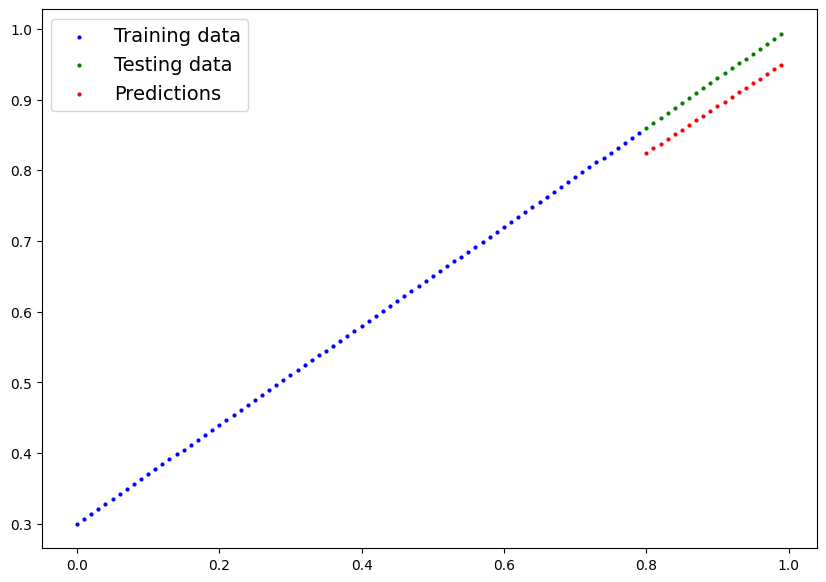

In [ ]:
model_2.eval()
with torch.inference_mode():
  y_pred_test_reg=model_2(X_test_reg)

# Plot Prediction

## Numpy uses CPU so you will get an error so get all tensor to CPU
plot_predictions(X_train_reg.cpu(),
                 y_train_reg.cpu(),
                 X_test_reg.cpu(),
                 y_test_reg.cpu(),
                 y_pred_test_reg.cpu()
                 )

# Recreating Non-Linear Data

In [ ]:
n_samples=1000
X,y=make_circles(n_samples,noise=0.03,random_state=42)
print(X.shape,y.shape)
# plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdBu)

# Convert Data to tensor and then Train and test split

X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

#Split
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=42)

X_train[:5]

(1000, 2) (1000,)


tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]])

In [ ]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=10)
    self.layer_4=nn.Linear(in_features=10,out_features=1)
    self.relu=nn.ReLU()  # Non-Linear Acctivation function
  def forward(self,x:torch):
    return self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x))) ))))

model_3=CircleModelV2()
model_3=model_3.to(device)

next(model_3.parameters())


Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153],
        [ 0.6233, -0.5188],
        [ 0.6146,  0.1323],
        [ 0.5224,  0.0958],
        [ 0.3410, -0.0998],
        [ 0.5451,  0.1045],
        [-0.3301,  0.1802]], device='cuda:0', requires_grad=True)

In [ ]:
# Loss

loss_fn_3=nn.L1Loss()
optimizer_3=torch.optim.SGD(params=model_3.parameters(),lr=0.1)

In [ ]:
epochs=1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)


# Putting on same device

X_train, y_train= X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):

  model_3.train()

  # Forward Pass
  y_logits=model_3(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))


  # Calculate Loss and Accuracy
  loss=loss_fn_3(y_logits,y_train)
  acc=accuracy_fn(y_train,y_pred)

  optimizer_3.zero_grad()
  loss.backward()
  optimizer_3.step()
  # print("Model device:", next(model_3.parameters()).device)
  # print("X_test device:", X_test.device)

  # Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    test_loss=loss_fn_3(test_logits,y_test)
    test_acc=accuracy_fn(y_test,test_pred)

  if epoch%100 == 0:
    print(f'Train loss {loss.item():.5f} | Test loss {test_loss.item():.5f} |  Train Accuracy {acc:.3f} | Test Accuracy {test_acc:.3f}')



Train loss 0.49926 | Test loss 0.49871 |  Train Accuracy 50.000 | Test Accuracy 50.000
Train loss 0.49780 | Test loss 0.49683 |  Train Accuracy 50.000 | Test Accuracy 50.000
Train loss 0.49505 | Test loss 0.49345 |  Train Accuracy 50.000 | Test Accuracy 50.000
Train loss 0.48819 | Test loss 0.48528 |  Train Accuracy 50.500 | Test Accuracy 50.000
Train loss 0.47407 | Test loss 0.46860 |  Train Accuracy 50.875 | Test Accuracy 51.500
Train loss 0.43889 | Test loss 0.42812 |  Train Accuracy 52.000 | Test Accuracy 52.000
Train loss 0.37073 | Test loss 0.35258 |  Train Accuracy 55.250 | Test Accuracy 50.500
Train loss 0.33513 | Test loss 0.44332 |  Train Accuracy 70.125 | Test Accuracy 50.000
Train loss 0.42381 | Test loss 0.28866 |  Train Accuracy 50.000 | Test Accuracy 55.000
Train loss 0.28751 | Test loss 0.27679 |  Train Accuracy 51.000 | Test Accuracy 65.000


In [ ]:
# Evaluating the Model

model_3.eval()
with torch.inference_mode():
  y_preds=torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_pred[:10],y_test[:10]

(tensor([1., 1., 0., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
        grad_fn=<SliceBackward0>),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

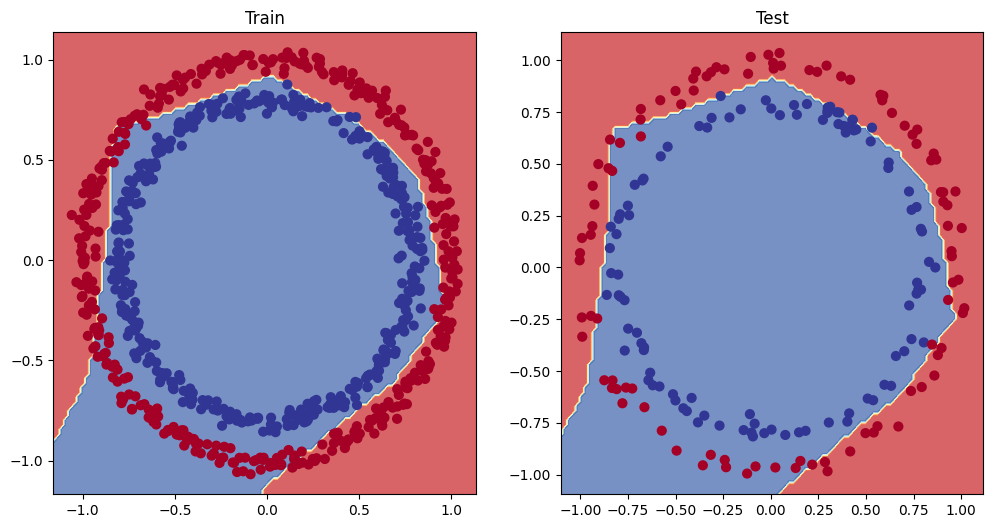

In [ ]:
# plot_predictions(X_train.cpu(),
#                  y_train.cpu(),
#                  X_test.cpu(),
#                  y_test.cpu())

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)

# 7. Replicating non_linear Activaion Function

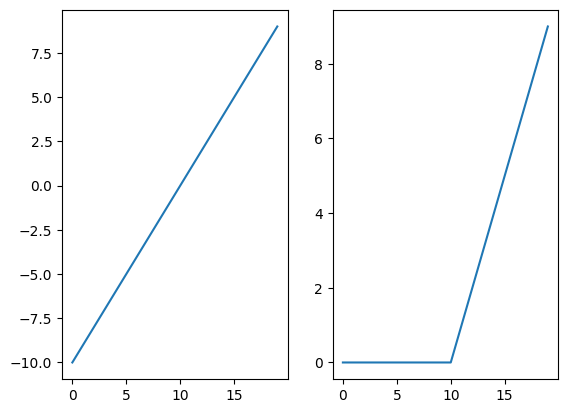

In [ ]:
# Create Tensor
A=torch.arange(-10,10,1,dtype=torch.float)

#Visaluize
plt.subplot(1,2,1)
plt.plot(A)
plt.subplot(1,2,2)
plt.plot(torch.relu(A))

ReLU = max(0,x)

In [ ]:
def relu(x:torch) -> torch.tensor:
  return torch.max(torch.tensor(0),x)
print(A.shape)
print(A)
relu(A)

torch.Size([20])
tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

# Sigmoid

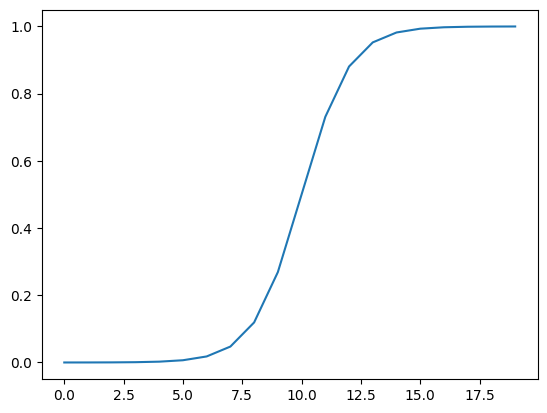

In [ ]:
# visualize
plt.plot(torch.sigmoid(A))

In [ ]:
def sigmoid_fn(x:torch):
  return 1/ (1 + torch.exp(-x))



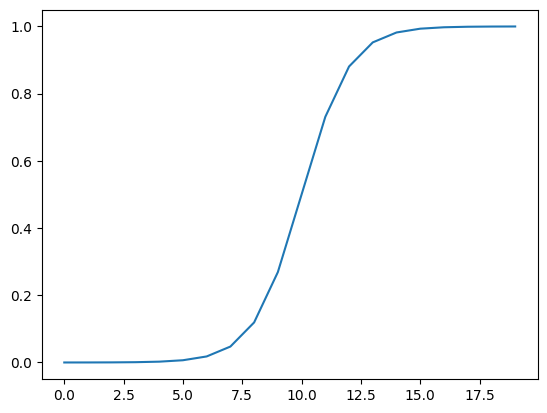

In [ ]:
plt.plot(sigmoid_fn(A))

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])